# MongoDB 데이터 읽기 → Pandas DataFrame 구성 간단 실습

## 실습 목표

이 노트북은 기존 `mongodb연결실습.ipynb`의 기본 흐름을 바탕으로, **MongoDB에 저장된 document를 읽어와 Pandas DataFrame으로 구성하는 가장 간단한 예제**를 제공합니다.

기존 실습 흐름은 다음과 같았습니다.

1. `MongoClient('localhost', 27017)`로 MongoDB 연결
2. `db = client.sample`처럼 데이터베이스 선택
3. `collection = db.test`처럼 컬렉션 선택
4. `insert_one()`, `insert_many()`로 document 입력
5. `find()`, `find_one()`, `sort()`로 데이터 조회
6. 필요 시 `update_one()`, `update_many()`, `delete_many()` 수행

이번 실습에서는 여기에 다음 과정을 추가합니다.

> `collection.find()` → `list()` → `pd.DataFrame()` → 데이터 확인 및 간단한 집계

---

## 실습 시나리오

간단한 물류센터 작업자 배정 데이터를 MongoDB에 저장한다고 가정합니다.

| 필드 | 의미 |
|---|---|
| `worker_name` | 작업자 이름 |
| `job` | 담당 작업 |
| `center` | 물류센터 |
| `shift` | 근무조 |
| `processed_boxes` | 처리 박스 수 |
| `error_count` | 오류 건수 |
| `work_date` | 작업일 |

이 데이터를 MongoDB에서 읽어온 뒤 DataFrame으로 변환하여, 작업별 처리량과 오류율을 간단히 분석합니다.

## 1. 라이브러리 불러오기

`pymongo`는 MongoDB와 Python을 연결하기 위한 라이브러리입니다.  
`pandas`는 MongoDB에서 읽어온 document 리스트를 DataFrame으로 바꾸기 위해 사용합니다.

In [1]:
import pandas as pd
import numpy as np

try:
    import pymongo
    from pymongo import MongoClient
    from pymongo.errors import ServerSelectionTimeoutError
    print('pymongo version:', pymongo.__version__)
except ImportError:
    pymongo = None
    MongoClient = None
    ServerSelectionTimeoutError = Exception
    print('pymongo가 설치되어 있지 않습니다. 필요한 경우 pip install pymongo를 실행하세요.')

print('pandas version:', pd.__version__)

pymongo version: 4.16.0
pandas version: 2.3.3


## 2. MongoDB 연결

기존 `mongodb연결실습.ipynb`와 동일하게 `localhost`, `27017` 포트로 MongoDB에 연결합니다.

```python
client = MongoClient('localhost', 27017)
db = client.sample
collection = db.test
```

이번 실습에서는 실습용 데이터베이스와 컬렉션 이름을 조금 더 명확하게 사용합니다.

- database: `logistics_practice`
- collection: `worker_daily_summary`

> MongoDB 서버가 실행 중이 아니어도 노트북의 전체 흐름을 확인할 수 있도록 fallback 예제를 함께 제공합니다.

In [2]:
# ------------------------------------------------------------
# MongoDB 연결
# ------------------------------------------------------------
# 기존 mongodb연결실습.ipynb의 기본 구조:
# client = MongoClient('localhost', 27017)
# db = client.sample
# collection = db.test
# ------------------------------------------------------------

mongo_available = False
client = None
collection = None

if MongoClient is not None:
    try:
        client = MongoClient('localhost', 27017, serverSelectionTimeoutMS=2000)
        # 실제 연결 가능 여부 확인
        client.admin.command('ping')
        db = client.logistics_practice
        collection = db.worker_daily_summary
        mongo_available = True
        print('MongoDB 연결 성공')
        print('Database:', db.name)
        print('Collection:', collection.name)
    except Exception as e:
        print('MongoDB 연결 실패:', type(e).__name__)
        print('MongoDB 서버가 실행 중이 아니면 fallback 데이터로 DataFrame 변환 흐름을 실습합니다.')
else:
    print('pymongo가 없어 MongoDB 연결을 건너뜁니다.')

MongoDB 연결 성공
Database: logistics_practice
Collection: worker_daily_summary


## 3. MongoDB에 넣을 예제 document 만들기

MongoDB는 행(row) 대신 **document** 단위로 데이터를 저장합니다.  
Python에서는 document를 보통 `dict` 형태로 표현합니다.

여러 document는 `list[dict]` 형태로 준비한 뒤 `insert_many()`로 입력할 수 있습니다.

In [3]:
# ------------------------------------------------------------
# MongoDB에 입력할 예제 document
# ------------------------------------------------------------
# 주석:
# - MongoDB document는 Python dict와 매우 유사합니다.
# - 여러 건을 넣을 때는 list 안에 dict를 여러 개 넣습니다.
# ------------------------------------------------------------

sample_docs = [
    {'worker_name': '김민수', 'job': 'picking', 'center': 'Goyang', 'shift': 'day',   'processed_boxes': 185, 'error_count': 2, 'work_date': '2026-01-02'},
    {'worker_name': '이서연', 'job': 'packing', 'center': 'Goyang', 'shift': 'night', 'processed_boxes': 210, 'error_count': 1, 'work_date': '2026-01-02'},
    {'worker_name': '박지훈', 'job': 'sorting', 'center': 'Incheon', 'shift': 'day',  'processed_boxes': 160, 'error_count': 4, 'work_date': '2026-01-02'},
    {'worker_name': '최유진', 'job': 'picking', 'center': 'Incheon', 'shift': 'night','processed_boxes': 198, 'error_count': 3, 'work_date': '2026-01-03'},
    {'worker_name': '정하늘', 'job': 'packing', 'center': 'Gimpo', 'shift': 'day',    'processed_boxes': 230, 'error_count': 0, 'work_date': '2026-01-03'},
    {'worker_name': '한도윤', 'job': 'sorting', 'center': 'Gimpo', 'shift': 'night',  'processed_boxes': 175, 'error_count': 2, 'work_date': '2026-01-03'},
    {'worker_name': '오지민', 'job': 'picking', 'center': 'Goyang', 'shift': 'day',   'processed_boxes': 205, 'error_count': 1, 'work_date': '2026-01-04'},
    {'worker_name': '윤서준', 'job': 'packing', 'center': 'Incheon', 'shift': 'night','processed_boxes': 190, 'error_count': 5, 'work_date': '2026-01-04'}
]

sample_docs[:2]

[{'worker_name': '김민수',
  'job': 'picking',
  'center': 'Goyang',
  'shift': 'day',
  'processed_boxes': 185,
  'error_count': 2,
  'work_date': '2026-01-02'},
 {'worker_name': '이서연',
  'job': 'packing',
  'center': 'Goyang',
  'shift': 'night',
  'processed_boxes': 210,
  'error_count': 1,
  'work_date': '2026-01-02'}]

## 4. MongoDB에 document 입력하기

실습을 반복 실행해도 데이터가 중복되지 않도록 먼저 컬렉션을 비운 뒤 입력합니다.

```python
collection.delete_many({})
collection.insert_many(sample_docs)
```

- `delete_many({})`: 조건 없이 전체 삭제
- `insert_many(list_of_dict)`: 여러 document 입력

In [4]:
# ------------------------------------------------------------
# MongoDB에 document 입력
# ------------------------------------------------------------
# 주석:
# - MongoDB 서버가 연결되어 있으면 실제 collection에 넣습니다.
# - 연결되어 있지 않으면 이 단계는 건너뛰고 sample_docs를 직접 사용합니다.
# ------------------------------------------------------------

if mongo_available:
    collection.delete_many({})
    result = collection.insert_many(sample_docs)
    print('insert_many 완료')
    print('입력된 document 수:', len(result.inserted_ids))
else:
    print('MongoDB 미연결 상태이므로 insert_many 단계는 건너뜁니다.')
    print('대신 sample_docs 리스트를 MongoDB에서 읽어온 결과처럼 사용합니다.')

insert_many 완료
입력된 document 수: 8


## 5. MongoDB에서 데이터 읽기

기존 `mongodb연결실습.ipynb`에서는 다음과 같이 조회했습니다.

```python
for item in collection.find():
    print(item)
```

이 방식은 document를 하나씩 확인할 때 좋습니다.  
하지만 데이터 분석을 하려면 조회 결과를 DataFrame으로 바꾸는 것이 편리합니다.

In [5]:
# ------------------------------------------------------------
# find()로 document 읽기
# ------------------------------------------------------------
# 주석:
# - collection.find()는 cursor를 반환합니다.
# - cursor는 반복 가능한 객체이므로 for문으로 하나씩 출력할 수 있습니다.
# ------------------------------------------------------------

if mongo_available:
    for item in collection.find().limit(3):
        print(item)
else:
    for item in sample_docs[:3]:
        print(item)

{'_id': ObjectId('6a1b5f95c9faced8c8d16fff'), 'worker_name': '김민수', 'job': 'picking', 'center': 'Goyang', 'shift': 'day', 'processed_boxes': 185, 'error_count': 2, 'work_date': '2026-01-02'}
{'_id': ObjectId('6a1b5f95c9faced8c8d17000'), 'worker_name': '이서연', 'job': 'packing', 'center': 'Goyang', 'shift': 'night', 'processed_boxes': 210, 'error_count': 1, 'work_date': '2026-01-02'}
{'_id': ObjectId('6a1b5f95c9faced8c8d17001'), 'worker_name': '박지훈', 'job': 'sorting', 'center': 'Incheon', 'shift': 'day', 'processed_boxes': 160, 'error_count': 4, 'work_date': '2026-01-02'}


## 6. MongoDB 조회 결과를 DataFrame으로 변환하기

핵심 코드는 아래 한 줄입니다.

```python
read_df = pd.DataFrame(list(collection.find()))
```

흐름은 다음과 같습니다.

1. `collection.find()`로 MongoDB document 조회
2. `list()`로 cursor를 list of dict로 변환
3. `pd.DataFrame()`으로 표 형태 변환

MongoDB에서 읽은 데이터에는 보통 `_id` 컬럼이 포함됩니다.  
분석용 DataFrame에서는 `_id`를 문자열로 바꾸거나 삭제할 수 있습니다.

In [6]:
# ------------------------------------------------------------
# MongoDB 데이터 → DataFrame 변환
# ------------------------------------------------------------
# 핵심:
# records = list(collection.find())
# df = pd.DataFrame(records)
# ------------------------------------------------------------

if mongo_available:
    records = list(collection.find())
else:
    # MongoDB가 없을 때도 같은 구조를 실습하기 위한 fallback
    records = sample_docs

worker_df = pd.DataFrame(records)

print('DataFrame 크기:', worker_df.shape)
worker_df.head()

DataFrame 크기: (8, 8)


,_id,worker_name,job,center,shift,processed_boxes,error_count,work_date
0,6a1b5f95c9faced8c8d16fff,김민수,picking,Goyang,day,185,2,2026-01-02
1,6a1b5f95c9faced8c8d17000,이서연,packing,Goyang,night,210,1,2026-01-02
2,6a1b5f95c9faced8c8d17001,박지훈,sorting,Incheon,day,160,4,2026-01-02
3,6a1b5f95c9faced8c8d17002,최유진,picking,Incheon,night,198,3,2026-01-03
4,6a1b5f95c9faced8c8d17003,정하늘,packing,Gimpo,day,230,0,2026-01-03


In [7]:
# ------------------------------------------------------------
# _id 컬럼 처리
# ------------------------------------------------------------
# 주석:
# - MongoDB에서 읽어온 경우 _id는 ObjectId 타입입니다.
# - 분석에 필요 없으면 삭제하거나, 추적용으로 문자열 변환합니다.
# ------------------------------------------------------------

worker_df_clean = worker_df.copy()

if '_id' in worker_df_clean.columns:
    worker_df_clean['_id'] = worker_df_clean['_id'].astype(str)
    print('_id 컬럼을 문자열로 변환했습니다.')
else:
    print('fallback 데이터에는 _id 컬럼이 없습니다.')

worker_df_clean.head()

_id 컬럼을 문자열로 변환했습니다.


,_id,worker_name,job,center,shift,processed_boxes,error_count,work_date
0,6a1b5f95c9faced8c8d16fff,김민수,picking,Goyang,day,185,2,2026-01-02
1,6a1b5f95c9faced8c8d17000,이서연,packing,Goyang,night,210,1,2026-01-02
2,6a1b5f95c9faced8c8d17001,박지훈,sorting,Incheon,day,160,4,2026-01-02
3,6a1b5f95c9faced8c8d17002,최유진,picking,Incheon,night,198,3,2026-01-03
4,6a1b5f95c9faced8c8d17003,정하늘,packing,Gimpo,day,230,0,2026-01-03


## 7. DataFrame 기본 확인

MongoDB에서 가져온 데이터를 DataFrame으로 구성했다면 일반적인 Pandas 분석을 바로 적용할 수 있습니다.

확인할 내용은 다음과 같습니다.

- 컬럼명
- 데이터 타입
- 결측치
- 기초 통계

In [8]:
# DataFrame 구조 확인
print('컬럼 목록')
print(worker_df_clean.columns.tolist())

print()
print('데이터 타입')
display(worker_df_clean.dtypes)

print()
print('결측치 개수')
display(worker_df_clean.isna().sum())

print()
print('기초 통계')
display(worker_df_clean.describe(include='all'))

컬럼 목록
['_id', 'worker_name', 'job', 'center', 'shift', 'processed_boxes', 'error_count', 'work_date']

데이터 타입


_id                object
worker_name        object
job                object
center             object
shift              object
processed_boxes     int64
error_count         int64
work_date          object
dtype: object


결측치 개수


_id                0
worker_name        0
job                0
center             0
shift              0
processed_boxes    0
error_count        0
work_date          0
dtype: int64


기초 통계


,_id,worker_name,job,center,shift,processed_boxes,error_count,work_date
count,8,8,8,8,8,8.000000,8.000000,8
unique,8,8,3,3,2,NaN,NaN,3
top,6a1b5f95c9faced8c8d16fff,김민수,picking,Goyang,day,NaN,NaN,2026-01-02
freq,1,1,3,3,4,NaN,NaN,3
mean,NaN,NaN,NaN,NaN,NaN,194.125000,2.250000,NaN
std,NaN,NaN,NaN,NaN,NaN,21.721862,1.669046,NaN
min,NaN,NaN,NaN,NaN,NaN,160.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,182.500000,1.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,194.000000,2.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,206.250000,3.250000,NaN


## 8. 날짜 타입 변환 및 파생 컬럼 만들기

MongoDB에서 읽어온 날짜가 문자열이면 Pandas에서 날짜형으로 바꾸어야 합니다.

또한 오류율을 다음과 같이 계산합니다.

\[
오류율 = 오류건수 / 처리박스수
\]

이처럼 MongoDB는 저장소 역할을 하고, Pandas는 분석용 데이터 처리 도구 역할을 합니다.

In [9]:
# ------------------------------------------------------------
# 날짜 변환 및 파생변수 생성
# ------------------------------------------------------------
# 주석:
# - pd.to_datetime()으로 문자열 날짜를 datetime으로 변환합니다.
# - error_rate는 처리량 대비 오류 비율입니다.
# ------------------------------------------------------------

worker_df_clean['work_date'] = pd.to_datetime(worker_df_clean['work_date'])
worker_df_clean['error_rate'] = worker_df_clean['error_count'] / worker_df_clean['processed_boxes']

worker_df_clean.head()

,_id,worker_name,job,center,shift,processed_boxes,error_count,work_date,error_rate
0,6a1b5f95c9faced8c8d16fff,김민수,picking,Goyang,day,185,2,2026-01-02,0.010811
1,6a1b5f95c9faced8c8d17000,이서연,packing,Goyang,night,210,1,2026-01-02,0.004762
2,6a1b5f95c9faced8c8d17001,박지훈,sorting,Incheon,day,160,4,2026-01-02,0.025000
3,6a1b5f95c9faced8c8d17002,최유진,picking,Incheon,night,198,3,2026-01-03,0.015152
4,6a1b5f95c9faced8c8d17003,정하늘,packing,Gimpo,day,230,0,2026-01-03,0.000000


## 9. MongoDB 조건 조회 후 DataFrame 구성

MongoDB에서 조건을 걸어 일부 document만 읽을 수 있습니다.

예를 들어 `center == 'Goyang'`인 데이터만 읽으려면 다음과 같이 작성합니다.

```python
collection.find({'center': 'Goyang'})
```

DataFrame으로 바꾸는 방식은 동일합니다.

In [10]:
# ------------------------------------------------------------
# 조건 조회 결과를 DataFrame으로 변환
# ------------------------------------------------------------
# 주석:
# - MongoDB 연결 시에는 find({'center': 'Goyang'})을 사용합니다.
# - fallback에서는 Pandas 필터링으로 같은 결과를 만듭니다.
# ------------------------------------------------------------

if mongo_available:
    goyang_records = list(collection.find({'center': 'Goyang'}))
    goyang_df = pd.DataFrame(goyang_records)
    if '_id' in goyang_df.columns:
        goyang_df['_id'] = goyang_df['_id'].astype(str)
else:
    goyang_df = pd.DataFrame([doc for doc in sample_docs if doc['center'] == 'Goyang'])

goyang_df

,_id,worker_name,job,center,shift,processed_boxes,error_count,work_date
0,6a1b5f95c9faced8c8d16fff,김민수,picking,Goyang,day,185,2,2026-01-02
1,6a1b5f95c9faced8c8d17000,이서연,packing,Goyang,night,210,1,2026-01-02
2,6a1b5f95c9faced8c8d17005,오지민,picking,Goyang,day,205,1,2026-01-04


## 10. MongoDB 정렬 조회 후 DataFrame 구성

기존 `mongodb연결실습.ipynb`에는 `sort()` 예제가 있었습니다.

```python
collection.find().sort('이름')
collection.find().sort('이름', pymongo.DESCENDING)
```

이번 실습에서는 처리 박스 수(`processed_boxes`)가 많은 순서로 정렬해봅니다.

In [11]:
# ------------------------------------------------------------
# 정렬 조회 결과를 DataFrame으로 변환
# ------------------------------------------------------------
# 주석:
# - MongoDB 연결 시 sort('processed_boxes', pymongo.DESCENDING)를 사용합니다.
# - fallback에서는 Pandas sort_values()로 같은 결과를 만듭니다.
# ------------------------------------------------------------

if mongo_available:
    sorted_records = list(collection.find().sort('processed_boxes', pymongo.DESCENDING))
    sorted_df = pd.DataFrame(sorted_records)
    if '_id' in sorted_df.columns:
        sorted_df['_id'] = sorted_df['_id'].astype(str)
else:
    sorted_df = pd.DataFrame(sample_docs).sort_values('processed_boxes', ascending=False)

sorted_df.head()

,_id,worker_name,job,center,shift,processed_boxes,error_count,work_date
0,6a1b5f95c9faced8c8d17003,정하늘,packing,Gimpo,day,230,0,2026-01-03
1,6a1b5f95c9faced8c8d17000,이서연,packing,Goyang,night,210,1,2026-01-02
2,6a1b5f95c9faced8c8d17005,오지민,picking,Goyang,day,205,1,2026-01-04
3,6a1b5f95c9faced8c8d17002,최유진,picking,Incheon,night,198,3,2026-01-03
4,6a1b5f95c9faced8c8d17006,윤서준,packing,Incheon,night,190,5,2026-01-04


## 11. Pandas로 간단한 집계 분석

MongoDB에서 읽어온 데이터를 DataFrame으로 변환하면 `groupby()`를 사용할 수 있습니다.

아래에서는 작업 유형(`job`)별로 다음 지표를 계산합니다.

- 평균 처리 박스 수
- 총 오류 건수
- 평균 오류율

In [12]:
# ------------------------------------------------------------
# 작업 유형별 집계
# ------------------------------------------------------------
# 주석:
# - MongoDB에서 읽어온 데이터도 DataFrame이 되면 일반 Pandas 데이터와 동일하게 처리할 수 있습니다.
# ------------------------------------------------------------

job_summary = (
    worker_df_clean
    .groupby('job')
    .agg(
        avg_processed_boxes=('processed_boxes', 'mean'),
        total_error_count=('error_count', 'sum'),
        avg_error_rate=('error_rate', 'mean'),
        worker_count=('worker_name', 'count')
    )
    .reset_index()
    .sort_values('avg_processed_boxes', ascending=False)
)

job_summary

,job,avg_processed_boxes,total_error_count,avg_error_rate,worker_count
0,packing,210.0,6,0.010359,3
1,picking,196.0,6,0.010280,3
2,sorting,167.5,6,0.018214,2


## 12. MongoDB aggregation 결과를 DataFrame으로 변환하기

MongoDB 자체에서도 집계 연산을 할 수 있습니다.  
예를 들어 작업 유형별 평균 처리량을 MongoDB aggregation pipeline으로 계산할 수 있습니다.

```python
pipeline = [
    {'$group': {'_id': '$job', 'avg_processed_boxes': {'$avg': '$processed_boxes'}}}
]
result = list(collection.aggregate(pipeline))
pd.DataFrame(result)
```

실무에서는 다음처럼 역할을 나누어 사용할 수 있습니다.

- MongoDB: 대량 데이터 저장, 조건 조회, 1차 필터링
- Pandas: 세부 정제, 통계, 시각화, 분석 리포트 작성

In [13]:
# ------------------------------------------------------------
# MongoDB aggregation 결과 → DataFrame
# ------------------------------------------------------------
# 주석:
# - MongoDB 서버가 있으면 실제 aggregation을 실행합니다.
# - 서버가 없으면 Pandas groupby 결과를 MongoDB aggregation 결과 형태로 흉내냅니다.
# ------------------------------------------------------------

if mongo_available:
    pipeline = [
        {
            '$group': {
                '_id': '$job',
                'avg_processed_boxes': {'$avg': '$processed_boxes'},
                'total_error_count': {'$sum': '$error_count'},
                'count': {'$sum': 1}
            }
        },
        {'$sort': {'avg_processed_boxes': -1}}
    ]
    agg_records = list(collection.aggregate(pipeline))
    agg_df = pd.DataFrame(agg_records).rename(columns={'_id': 'job'})
else:
    agg_df = job_summary[['job', 'avg_processed_boxes', 'total_error_count', 'worker_count']].rename(
        columns={'worker_count': 'count'}
    )

agg_df

,job,avg_processed_boxes,total_error_count,count
0,packing,210.0,6,3
1,picking,196.0,6,3
2,sorting,167.5,6,2


## 13. 간단한 시각화

마지막으로 MongoDB에서 읽어와 DataFrame으로 구성한 데이터를 간단히 시각화합니다.

작업 유형별 평균 처리 박스 수를 막대그래프로 확인합니다.

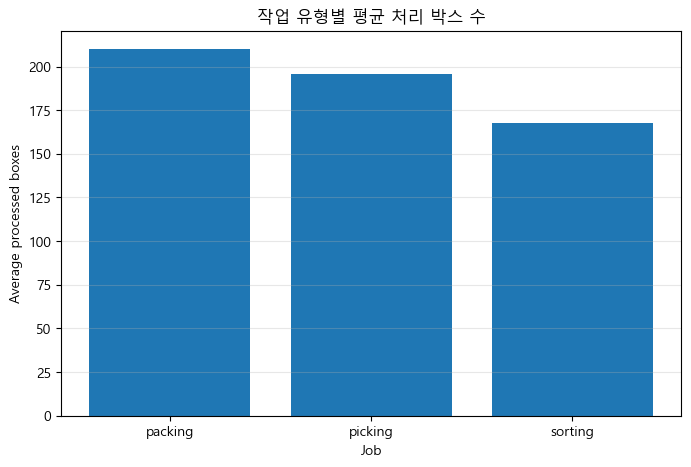

In [14]:
import matplotlib.pyplot as plt

import platform

path = "c:/fonts/malgun.ttf"
from matplotlib import font_manager, rc
if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~') 
    
plt.figure(figsize=(8, 5))
plt.bar(job_summary['job'], job_summary['avg_processed_boxes'])
plt.title('작업 유형별 평균 처리 박스 수')
plt.xlabel('Job')
plt.ylabel('Average processed boxes')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 14. 실습 정리

이번 실습의 핵심 코드는 다음과 같습니다.

```python
client = MongoClient('localhost', 27017)
db = client.logistics_practice
collection = db.worker_daily_summary

records = list(collection.find())
df = pd.DataFrame(records)
```

전체 흐름은 다음과 같습니다.

1. MongoDB 연결
2. 데이터베이스 선택
3. 컬렉션 선택
4. document 입력 또는 기존 document 조회
5. `find()` 결과를 `list`로 변환
6. `pd.DataFrame()`으로 분석용 테이블 구성
7. Pandas로 타입 변환, 파생 변수 생성, groupby 집계
8. Matplotlib으로 간단한 시각화

이 노트북은 MongoDB와 Pandas를 연결하는 가장 기본적인 형태의 실습입니다.